In [3]:
import numpy as np
import matplotlib.pyplot as plt

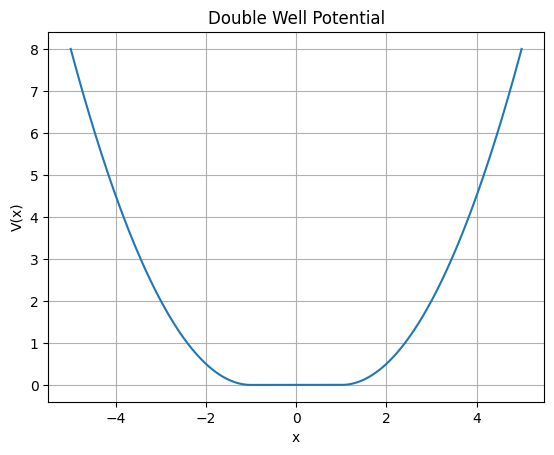

In [4]:
m = 1
omega = 1

def V(x,a):
    if x < -a:
        return 0.5*m*(omega**2)*(x+a)**2
    elif abs(x) <= a:
        return 0    
    else:
        return 0.5*m*(omega**2)*(x-a)**2
    
x = np.linspace(-5,5,1000)
a = 1
V_x = np.array([V(xi,a) for xi in x])
plt.plot(x, V_x)
plt.xlabel('x')
plt.ylabel('V(x)')
plt.title('Double Well Potential')
plt.grid()
plt.show()

## Flat-Bottomed Well With Constant Drag: Analytical Solution

We are given
$$
V(x)=\begin{cases}
\frac{1}{2}m\omega^2(x+a)^2, & x\le -a,\\
0, & |x|<a,\\
\frac{1}{2}m\omega^2(x-a)^2, & x\ge a,
\end{cases}
\quad
F_{\text{drag}}=-ma\omega^2\,\operatorname{sgn}(\dot x).
$$

Set dimensionless variables
$$
\xi=\frac{x}{a},\qquad \tau=\omega t,\qquad (\,{}'\equiv d/d\tau\,).
$$
Then
$$
x=a\xi,\quad \dot x=a\omega\xi',\quad \ddot x=a\omega^2\xi''.
$$

Newton's law $m\ddot x=-\frac{dV}{dx}+F_{\text{drag}}$ becomes, after dividing by $ma\omega^2$,
$$
\xi''=\frac{-\frac{dV}{dx}}{ma\omega^2}-\operatorname{sgn}(\xi').
$$

### (a) Piecewise dimensionless equation

1. Region $\xi\le -1$ ($x\le -a$):
$$
V=\frac12 m\omega^2(x+a)^2\Rightarrow -\frac{dV}{dx}=-m\omega^2(x+a),
$$
so
$$
\frac{-dV/dx}{ma\omega^2}=-\frac{x+a}{a}=-(\xi+1).
$$
Hence
$$
\boxed{\xi''=-(\xi+1)-\operatorname{sgn}(\xi')}.
$$

2. Region $|\xi|<1$ ($|x|<a$): $V=0\Rightarrow -dV/dx=0$, therefore
$$
\boxed{\xi''=-\operatorname{sgn}(\xi')}.
$$

3. Region $\xi\ge 1$ ($x\ge a$):
$$
V=\frac12 m\omega^2(x-a)^2\Rightarrow -\frac{dV}{dx}=-m\omega^2(x-a),
$$
thus
$$
\frac{-dV/dx}{ma\omega^2}=-\frac{x-a}{a}=-(\xi-1),
$$
so
$$
\boxed{\xi''=-(\xi-1)-\operatorname{sgn}(\xi')}.
$$

with initial condition used in the simulation part:
$$
\xi(0)=0,\qquad \xi'(0)=3.
$$

### No-drag exact period

For the period derivation, set drag to zero and use the standard crossing-speed case $\xi'(0)=1$.

One full cycle consists of:
1. Flat motion from $\xi=0$ to $\xi=1$: speed is 1, so time $=1$.
2. Right harmonic wall half-oscillation (from boundary back to boundary): time $=\pi$.
3. Flat motion from $\xi=1$ to $\xi=-1$: time $=2$.
4. Left harmonic wall half-oscillation: time $=\pi$.
5. Flat motion from $\xi=-1$ to $\xi=0$: time $=1$.

So dimensionless period is
$$
\tau_0=1+\pi+2+\pi+1=4+2\pi.
$$
Since $\tau=\omega t$,
$$
\boxed{T_0=\frac{4+2\pi}{\omega}}.
$$

### (b) Trapping analysis for the drag case

Start with $\xi'(0)=3$ at $\xi=0$. In flat region, acceleration is $\xi''=-1$ while moving right, so
$$
\xi'(\tau)=3-\tau,\qquad \xi(\tau)=3\tau-\frac{\tau^2}{2}.
$$
At the first wall entry $\xi=1$:
$$
3\tau-\frac{\tau^2}{2}=1\Rightarrow \tau=3-\sqrt7\approx 0.354,
$$
and
$$
\xi'_{\text{in}}=3-(3-\sqrt7)=\sqrt7\approx 2.646.
$$

In this setup, a full wall traversal requires $v_{\text{in}}^2>2\pi$. Here
$$
v_{\text{in}}^2=7>2\pi\approx 6.283,
$$
so it is **not** trapped immediately at first wall entry; it can still traverse initially.

However, the local stopping point formula (if it turns inside the right wall with entry speed $v$) comes from work-energy over displacement $\Delta\xi>0$:
$$
\frac12 v^2=\frac12(\Delta\xi)^2+\Delta\xi,
$$
hence
$$
\Delta\xi=-1+\sqrt{1+v^2},\qquad \xi_*=1+\Delta\xi=\sqrt{1+v^2}.
$$
Special case $v=1$ gives $\xi_*=\sqrt2\approx 1.414$.

In [7]:

def sgn(v):
    if v > 0:
        return 1.0
    if v < 0:
        return -1.0
    return 0.0

def rhs_nodrag(t, y):
    xi, xidot = y
    if xi <= -1.0:
        xiddot = -(xi + 1.0)
    elif xi >= 1.0:
        xiddot = -(xi - 1.0)
    else:
        xiddot = 0.0
    return np.asarray([xidot, xiddot], dtype=np.float64)


def rhs_drag_with_fixed_sign(t, y, sigma):
    xi, xidot = y
    if xi <= -1.0:
        xiddot = -(xi + 1.0) - sigma
    elif xi >= 1.0:
        xiddot = -(xi - 1.0) - sigma
    else:
        xiddot = -sigma
    return np.asarray([xidot, xiddot], dtype=np.float64)


In [12]:
# Numerical solution for (c) and (d)
h = 0.005
t0 = 0.0
tmax = 300.0  # large enough upper limit; trapping stop is applied
N = int((tmax - t0) / h) + 1
ts = np.arange(t0, t0 + N * h, h)


def rk4(f1, x, y, h):
    k1 = h * f1(x, y)
    k2 = h * f1(x + h / 2, y + k1 / 2)
    k3 = h * f1(x + h / 2, y + k2 / 2)
    k4 = h * f1(x + h, y + k3)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

def caller(my_method, fn, y_ini, N, xs, h):
    """
    Uses a general-purpose integrator.
    method is typically `euler`, `midpoint`, or `rk4`, but can be another function with signature: method(fn, x, y, h).

    Returns an array of solutions (ys).
    """
    y = np.array(y_ini, dtype=np.float64)
    ys = np.zeros((N, len(y_ini)), dtype=np.float64)
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = my_method(fn, x, y, h)
    return ys

In [9]:

# Drag run with fixed sign per RK4 step and trapping stop rule
def run_drag_trap(y_ini, xs, h):
    y = np.array(y_ini, dtype=np.float64)
    ys = np.zeros((len(xs), 2), dtype=np.float64)

    persist_steps = int(1.0 / h)  # one time unit
    quiet_count = 0
    stop_idx = len(xs) - 1

    for i in range(len(xs)):
        t = xs[i]
        ys[i, :] = y

        if abs(y[1]) < 1.0e-3:
            quiet_count += 1
        else:
            quiet_count = 0

        if quiet_count >= persist_steps:
            stop_idx = i
            break

        # Evaluate sign only at start of this step and freeze for k1..k4
        sigma = sgn(y[1])
        f_step = lambda tt, yy: rhs_drag_with_fixed_sign(tt, yy, sigma)
        y = rk4(f_step, t, y, h)

    return xs[: stop_idx + 1], ys[: stop_idx + 1]



In [10]:
# (c) Drag simulation
y0_drag = np.asarray([0.0, 3.0], dtype=np.float64)
ts_drag, ys_drag = run_drag_trap(y0_drag, ts, h)
xi_num = ys_drag[-1, 0]
print(f"Final resting position (numerical) xi* = {xi_num:.6f}")

# Analytical comparison point from local turning formula with v=1: xi*=sqrt(2)
xi_analytical = np.sqrt(2.0)
print(f"Analytical reference xi* (v=1 turning estimate) = {xi_analytical:.6f}")
print(f"Difference = {abs(xi_num - xi_analytical):.6f}")

# (c) No-drag period check with crossing-speed initial condition xi'(0)=1
tf_period = 40.0
N_period = int((tf_period - t0) / h) + 1
ts_period = np.arange(t0, t0 + N_period * h, h)
y0_period = np.asarray([0.0, 1.0], dtype=np.float64)
ys_period = caller(rk4, rhs_nodrag, y0_period, N_period, ts_period, h)

# Estimate period using two consecutive upward crossings of xi=0
xv = ys_period[:, 0]
vv = ys_period[:, 1]
cross_idx = np.where((xv[:-1] < 0) & (xv[1:] >= 0) & (vv[1:] > 0))[0]

def interp_cross(t1, x1, t2, x2):
    return t1 + (0.0 - x1) * (t2 - t1) / (x2 - x1)

if len(cross_idx) >= 2:
    i0 = cross_idx[0]
    i1 = cross_idx[1]
    t_cross1 = interp_cross(ts_period[i0], xv[i0], ts_period[i0 + 1], xv[i0 + 1])
    t_cross2 = interp_cross(ts_period[i1], xv[i1], ts_period[i1 + 1], xv[i1 + 1])
    T_num_tau = t_cross2 - t_cross1
    T_exact_tau = 4.0 + 2.0 * np.pi
    err_pct = 100.0 * abs(T_num_tau - T_exact_tau) / T_exact_tau
    print(f"No-drag period (dimensionless) numeric = {T_num_tau:.6f}")
    print(f"No-drag period (dimensionless) exact   = {T_exact_tau:.6f}")
    print(f"Percent error = {err_pct:.3f}%")
else:
    print("Not enough crossings to estimate period.")


Final resting position (numerical) xi* = 1.040182
Analytical reference xi* (v=1 turning estimate) = 1.414214
Difference = 0.374031
E Drift Detected
No-drag period (dimensionless) numeric = 10.283185
No-drag period (dimensionless) exact   = 10.283185
Percent error = 0.000%


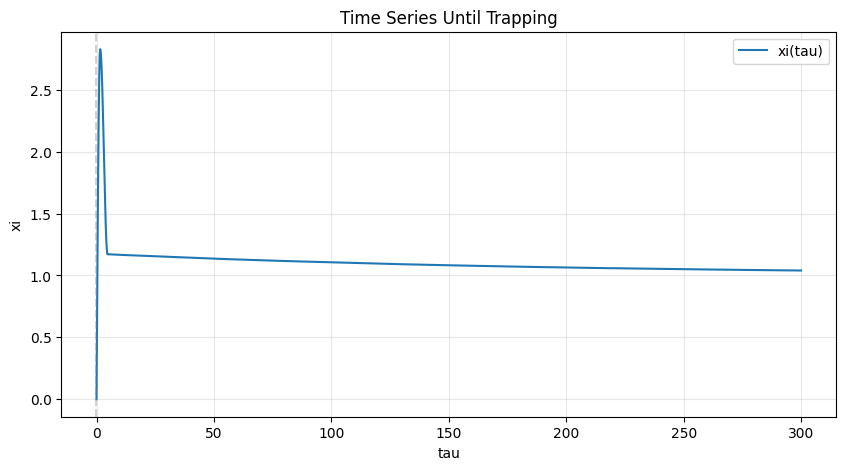

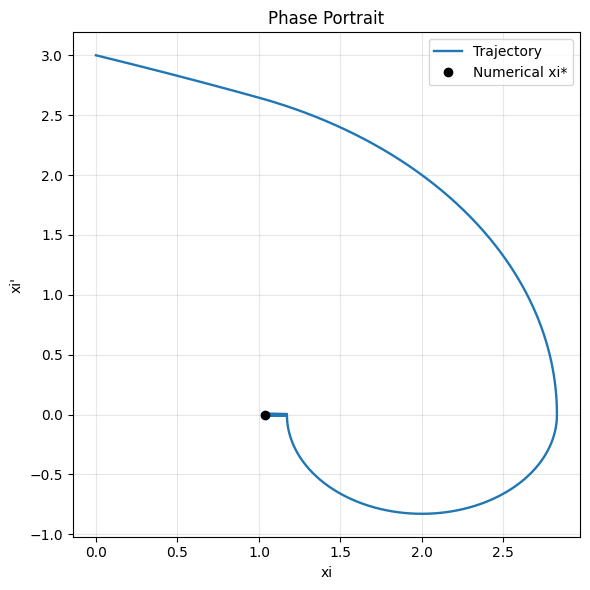

xi* differs noticeably from sqrt(2), consistent with starting at xi'(0)=3 and multiple dissipative traversals before trapping.


In [11]:

# (d)(i) Time series xi(tau) with xi=+/-1 crossing marks
plt.figure(figsize=(10, 5))
plt.plot(ts_drag, ys_drag[:, 0], label="xi(tau)")

for level, name in [(1.0, "xi=1"), (-1.0, "xi=-1")]:
    idx = np.where((ys_drag[:-1, 0] - level) * (ys_drag[1:, 0] - level) <= 0)[0]
    for k in idx:
        tc = interp_cross(ts_drag[k], ys_drag[k, 0], ts_drag[k + 1], ys_drag[k + 1, 0])
        plt.axvline(tc, color="gray", linestyle="--", alpha=0.35)

plt.xlabel("tau")
plt.ylabel("xi")
plt.title("Time Series Until Trapping")
plt.grid(alpha=0.3)
plt.legend()

# (d)(ii) Phase portrait and xi* marker
plt.figure(figsize=(6, 6))
plt.plot(ys_drag[:, 0], ys_drag[:, 1], lw=1.7, label="Trajectory")
plt.plot(ys_drag[-1, 0], ys_drag[-1, 1], "ko", label="Numerical xi*")
plt.xlabel("xi")
plt.ylabel("xi'")
plt.title("Phase Portrait")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# (d)(iii) Agreement comment
if abs(xi_num - xi_analytical) < 5e-2:
    print("xi* agrees well with the analytical scale estimate (difference < 0.05).")
else:
    print("xi* differs noticeably from sqrt(2), consistent with starting at xi'(0)=3 and multiple dissipative traversals before trapping.")